# FlowCast: Data Preprocessing
This notebook handles data loading, cleaning, and feature engineering for traffic prediction.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
# Load the traffic dataset
data = pd.read_csv('../data/raw/Traffic.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (2976, 9)


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


## 3. Data Exploration

In [3]:
# Basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [4]:
# Statistical summary
data.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64


In [6]:
# Check target variable distribution
print("Traffic Situation Distribution:")
print(data['Traffic Situation'].value_counts())

Traffic Situation Distribution:
Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64


## 4. Feature Engineering

In [7]:
# Extract time features from 'Time' column
data['hour'] = pd.to_datetime(data['Time']).dt.hour
data['minute'] = pd.to_datetime(data['Time']).dt.minute

# Extract AM/PM
data['AM/PM'] = data['Time'].apply(lambda x: 0 if 'AM' in x else 1)

print("Time features created successfully")

Time features created successfully


In [8]:
# Encode categorical variables
# Convert day of week to numeric
day_mapping = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 
               'Friday': 5, 'Saturday': 6, 'Sunday': 7}
data['Day of the week'] = data['Day of the week'].replace(day_mapping)

# Convert traffic situation to numeric (target variable)
situation_mapping = {'low': 0, 'normal': 1, 'heavy': 2, 'high': 3}
data['Traffic Situation'] = data['Traffic Situation'].replace(situation_mapping)

print("Categorical encoding completed")

Categorical encoding completed


In [9]:
# Drop unnecessary columns
data_processed = data.drop(columns=['Time'], axis=1)
print(f"Processed data shape: {data_processed.shape}")
data_processed.head()

Processed data shape: (2976, 11)


,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,hour,minute,AM/PM
0,10,2,31,0,4,4,39,0,0,0,0
1,10,2,49,0,3,3,55,0,0,15,0
2,10,2,46,0,3,6,55,0,0,30,0
3,10,2,51,0,2,5,58,0,0,45,0
4,10,2,57,6,15,16,94,1,1,0,0


## 5. Exploratory Data Analysis

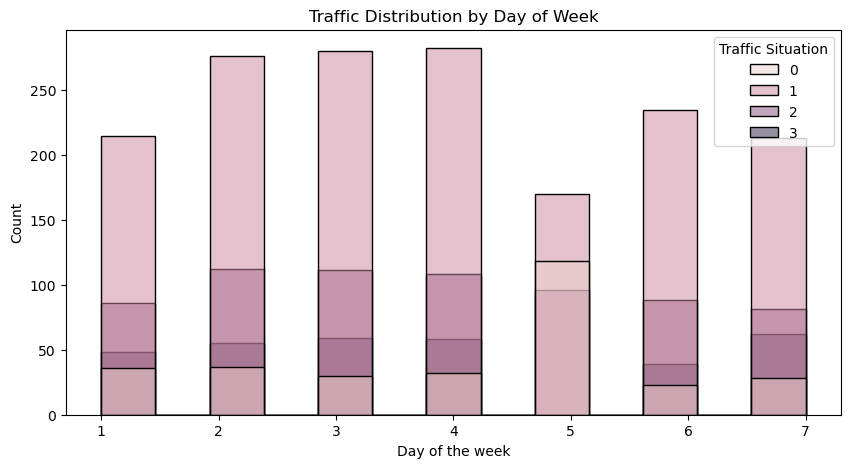

In [10]:
# Traffic situation by day of week
plt.figure(figsize=(10, 5))
sns.histplot(data=data_processed, x='Day of the week', hue='Traffic Situation')
plt.title('Traffic Distribution by Day of Week')
plt.show()

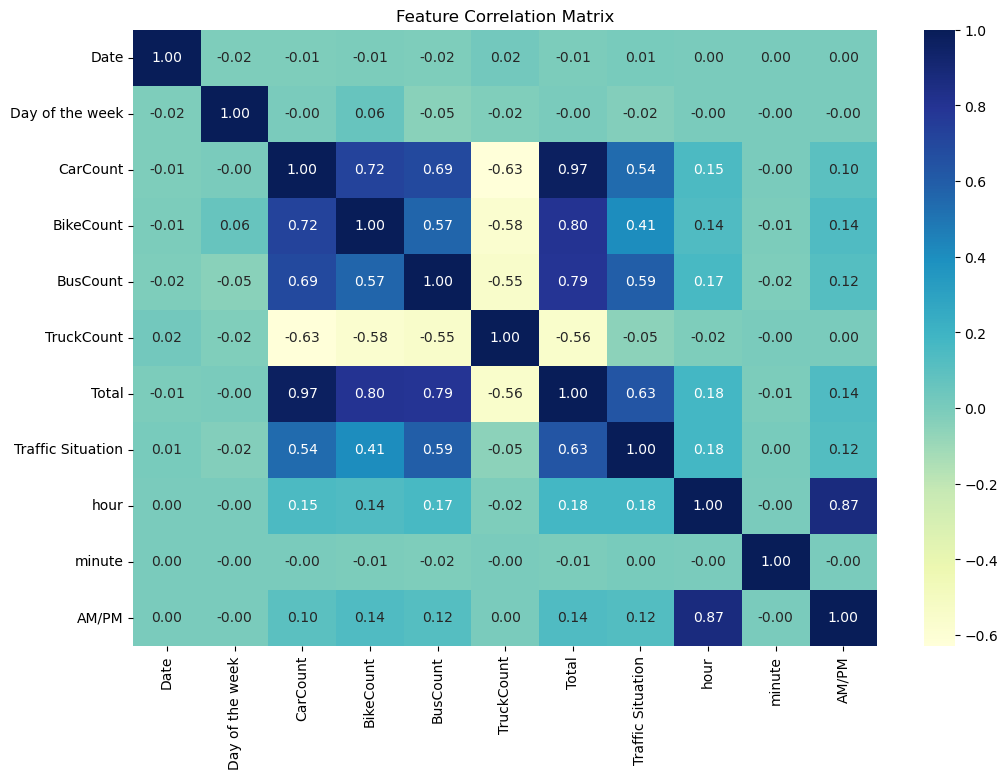

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data_processed.corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Feature Correlation Matrix')
plt.show()

## 6. Save Processed Data

In [12]:
# Save processed data for model training
data_processed.to_csv('../data/processed/traffic_processed.csv', index=False)
print("Processed data saved successfully!")

Processed data saved successfully!


## Summary
- Dataset loaded with no missing values
- Time features extracted (hour, minute, AM/PM)
- Categorical variables encoded
- Data ready for model training